In [9]:
import re
import pandas as pd
from datetime import datetime
from urlextract import URLExtract
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
#using file handling to read the chat data

f=open('badmooshi group chat.txt', 'r', encoding='utf-8') #utf-8 to read emojis
data=f.read()

In [11]:
print(data)

[08/03/25, 5:45:43 PM] badmooshi: ‎Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them.
[08/03/25, 5:45:43 PM] Naina Jain: ‎Naina Jain created group “🎳 ”
[08/03/25, 5:45:44 PM] badmooshi: ‎Naina Jain added you
[08/03/25, 5:46:46 PM] Neel Lapsiwala: ‎This message was deleted.
‎[08/03/25, 5:47:21 PM] Neel Lapsiwala: ‎video omitted
‎[08/03/25, 5:51:37 PM] Neel Lapsiwala: ‎video omitted
[08/03/25, 5:52:08 PM] Ritweek: 220 each
‎[08/03/25, 5:52:42 PM] Ritweek: ‎image omitted
[08/03/25, 10:44:14 PM] Naina Jain: ‎Naina Jain changed the group name to “🎳 Bowling”
[08/03/25, 10:44:35 PM] Naina Jain: Bowling wali video jiske pass hai wo bhejo
‎[09/03/25, 12:48:29 AM] Neel Lapsiwala: ‎video omitted
[09/03/25, 12:50:52 AM] badmooshi: ‎You changed the group name to “🎳 impromtu”
[11/03/25, 8:11:18 PM] Manav: @⁨Neel Lapsiwala⁩ photos isme hi bhej dena
[11/03/25, 8:11:53 PM] Nishchay(ai): Bhai jalane ke kaam kyu kar rhe ho🥲🥲🥲
‎[11/03/25, 8:12:03 PM] 

In [108]:
pattern=r'\[\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}:\d{2}\s(?:AM|PM)\]\s'  #pattern to identify date and time in the chat
message=re.split(pattern,data)[1:]  #splitting the data based on tHe pattern
user=[]
dm=[]
for i in message:
    entry=re.split('([\w\W]+?):\s',i)
    if entry[1:]:
        user.append(entry[1])
        dm.append(entry[2])
    # else:
    #     user.append('group_notification')
    #     dm.append(entry[0])

In [109]:
dates=re.findall(pattern,data)  #finding all the date and time using the pattern


In [110]:
a=[i.replace('[','') for i in dates]
a=[i.replace(']','').strip().replace(" "," ") for i in a]

d=[]
for i in a:
    dt = datetime.strptime(i, "%d/%m/%y, %I:%M:%S %p")
    d.append(dt.strftime('%Y-%m-%d, %H:%M'))

In [111]:
df=pd.DataFrame({'date':d,
                'user': user,
                'message':dm})
df

,date,user,message
0,"2025-03-08, 17:45",badmooshi,‎Messages and calls are end-to-end encrypted. ...
1,"2025-03-08, 17:45",Naina Jain,‎Naina Jain created group “🎳 ”\n
2,"2025-03-08, 17:45",badmooshi,‎Naina Jain added you\n
3,"2025-03-08, 17:46",Neel Lapsiwala,‎This message was deleted.\n‎
4,"2025-03-08, 17:47",Neel Lapsiwala,‎video omitted\n‎
...,...,...,...
35176,"2026-01-01, 00:30",Nishchay(ai),Nolan level shit banaya tha sab confuse😂😂\n‎
35177,"2026-01-01, 00:30",Manav,‎sticker omitted\n
35178,"2026-01-01, 09:05",Ritweek,Happy new year guys 🍷\n‎
35179,"2026-01-01, 09:06",Neel Lapsiwala,‎GIF omitted\n‎


In [112]:
group_name=df.iloc[0]['user']
df=df[(df['user']!=group_name)]
df.shape

(35177, 3)

In [ ]:
# df[df['user']=='You'].shape
df['user'].unique()

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [113]:
df['date']=pd.to_datetime(df['date'])

C:\Users\manav\AppData\Local\Temp\ipykernel_14776\1213281828.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date']=pd.to_datetime(df['date'])


In [114]:
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month_name()
df['day']=df['date'].dt.day
df['hour']=df['date'].dt.hour
df['minute']=df['date'].dt.minute




C:\Users\manav\AppData\Local\Temp\ipykernel_14776\3028861893.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year']=df['date'].dt.year
C:\Users\manav\AppData\Local\Temp\ipykernel_14776\3028861893.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month']=df['date'].dt.month_name()
C:\Users\manav\AppData\Local\Temp\ipykernel_14776\3028861893.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

In [20]:
words=[]
for i in df['message']:
    words.extend(i.split(' '))
print(len(words))


174796


In [21]:
count=0

for i in df['message']:
    if 'omitted' in re.findall('omitted',i):
        count+=1

print(count)

6165


In [22]:
urls=[]
extractor=URLExtract()
for i in df['message']:
    urls.extend(extractor.find_urls(i))
len(urls)

364

In [23]:
x=df['user'].value_counts().head()
x_values=x.index
y_values=x.values

In [24]:
(df['user'].value_counts()*100/df.shape[0]).reset_index().rename(columns={'user':'User','count':'Percentage'})

,User,Percentage
0,Nishchay(ai),26.295591
1,Naina Jain,22.361202
2,Manav,16.903090
3,Neel Lapsiwala,16.215141
4,Shreya (ai),12.567871
5,Ritweek,5.000426
6,Samvanvitha(ai),0.645308
7,‎You,0.011371


In [25]:
from collections import Counter
temp=df[df['user']!= 'group_notification']

pd.DataFrame(Counter(words).most_common(20))

,0,1
0,‎sticker,4438
1,omitted\n,4385
2,toh,2996
3,hai,2967
4,nhi,2244
5,hai\n,2163
6,hi,2010
7,bhi,1864
8,omitted\n‎,1780
9,ke,1524


In [26]:
temp['message']

1                    ‎Naina Jain created group “🎳 ”\n
3                       ‎This message was deleted.\n‎
4                                   ‎video omitted\n‎
5                                    ‎video omitted\n
6                                         220 each\n‎
                             ...                     
35176    Nolan level shit banaya tha sab confuse😂😂\n‎
35177                              ‎sticker omitted\n
35178                        Happy new year guys 🍷\n‎
35179                                 ‎GIF omitted\n‎
35180                                ‎image omitted\n
Name: message, Length: 35177, dtype: object

In [27]:
l=[]
for i in temp['message']:
    if 'omitted' not in i:
        l.extend(i.split(" "))
pd.DataFrame(Counter(l).most_common(20))

,0,1
0,toh,2996
1,hai,2967
2,nhi,2244
3,hai\n,2163
4,hi,2010
5,bhi,1864
6,ke,1524
7,ki,1372
8,me,1162
9,se,1124


In [28]:
import emoji

In [29]:
import emoji

emoj = []

for msg in df['message'].dropna():
    emoj.extend([e['emoji'] for e in emoji.emoji_list(msg)])
q=pd.DataFrame(Counter(emoj).most_common(10))
q.rename(columns=({0:'Emoji',1:'Emoji_count'}),inplace=True)


In [141]:
fig,ax=plt.Subplot(figsize=(10,5))
ax.bar(q['Emoji'],q['Emoji_count'])
plt.show()

TypeError: _AxesBase.__init__() missing 1 required positional argument: 'fig'

In [31]:
df['month_num']=df['date'].dt.month

C:\Users\manav\AppData\Local\Temp\ipykernel_14776\1439139282.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_num']=df['date'].dt.month


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35177 entries, 1 to 35180
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       35177 non-null  datetime64[ns]
 1   user       35177 non-null  object        
 2   message    35177 non-null  object        
 3   year       35177 non-null  int32         
 4   month      35177 non-null  object        
 5   day        35177 non-null  int32         
 6   hour       35177 non-null  int32         
 7   minute     35177 non-null  int32         
 8   month_num  35177 non-null  int32         
dtypes: datetime64[ns](1), int32(5), object(3)
memory usage: 2.0+ MB


In [33]:
timeline=df.groupby(['year','month_num','month']).count()['message'].reset_index()

In [34]:
t=[]
for i in range(timeline.shape[0]):
    t.append(timeline['month'][i] + '-' + str(timeline['year'][i]))

In [35]:
timeline['xlabels']=t
timeline

,year,month_num,month,message,xlabels
0,2025,3,March,1138,March-2025
1,2025,4,April,6145,April-2025
2,2025,5,May,3700,May-2025
3,2025,6,June,1257,June-2025
4,2025,7,July,2456,July-2025
5,2025,8,August,8001,August-2025
6,2025,9,September,5597,September-2025
7,2025,10,October,3202,October-2025
8,2025,11,November,2525,November-2025
9,2025,12,December,1123,December-2025


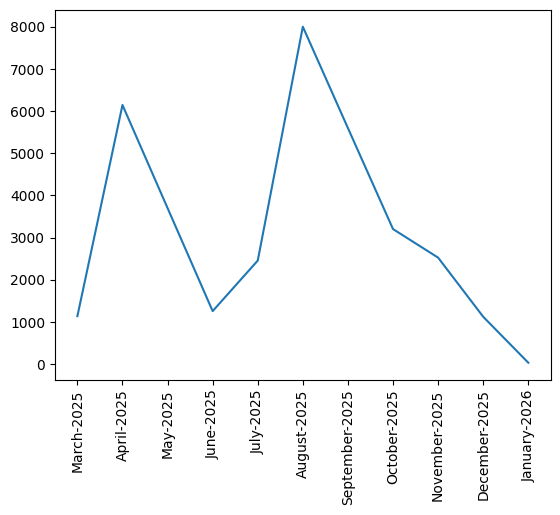

In [36]:
plt.plot(timeline['xlabels'],timeline['message'])
plt.xticks(rotation=90)
plt.show()

In [37]:
df['dates']=df['date'].dt.date
timeline_date=df.groupby(['dates']).count()['message'].reset_index()
timeline_date

C:\Users\manav\AppData\Local\Temp\ipykernel_14776\1026329626.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dates']=df['date'].dt.date


,dates,message
0,2025-03-08,8
1,2025-03-09,1
2,2025-03-11,220
3,2025-03-12,56
4,2025-03-13,48
...,...,...
256,2025-12-27,12
257,2025-12-29,2
258,2025-12-30,64
259,2025-12-31,58


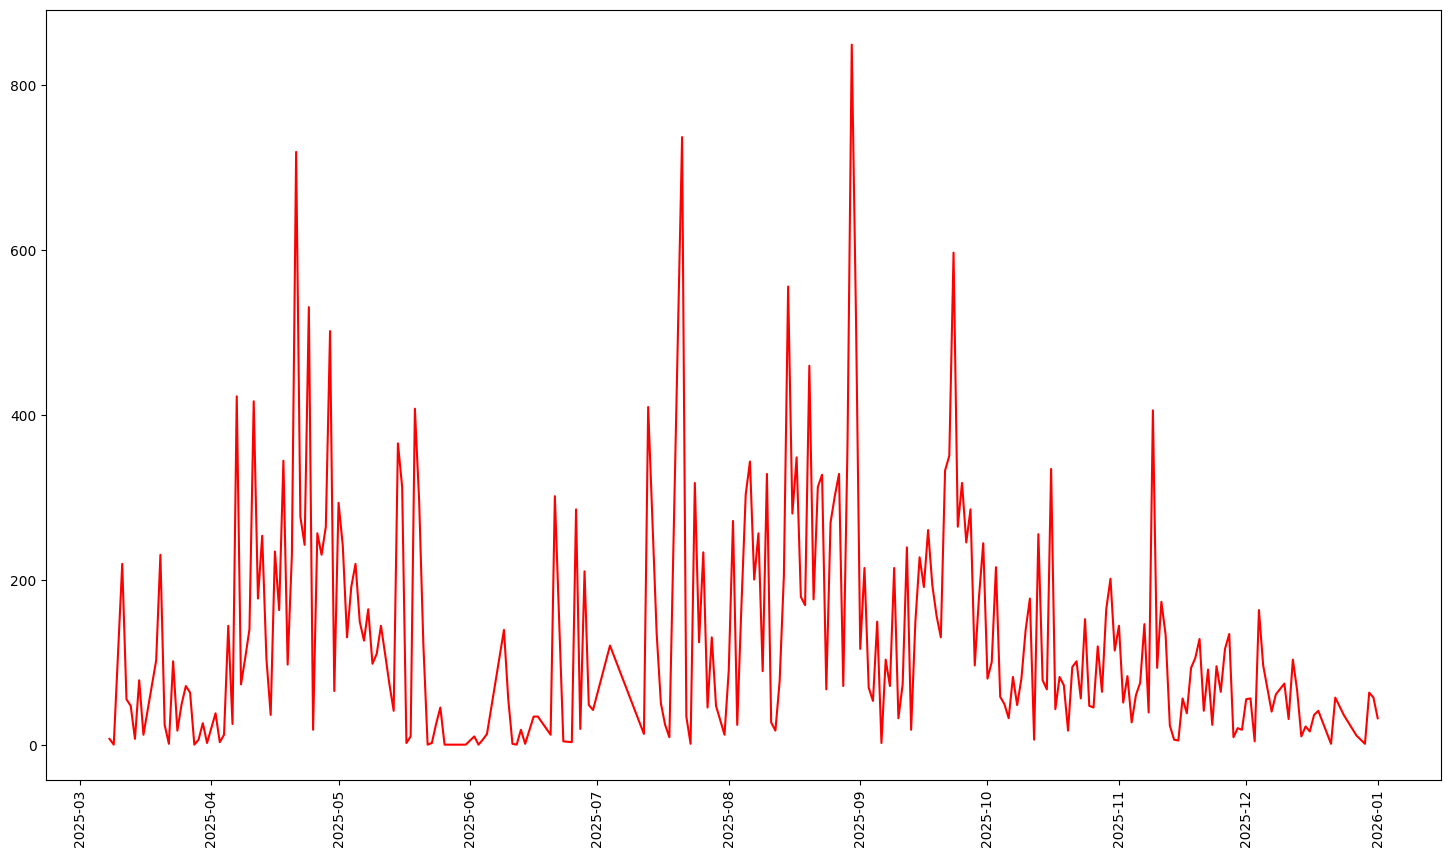

In [38]:
fig, ax = plt.subplots(figsize=(18,10))
ax.plot(timeline_date['dates'],timeline_date['message'], color='red')
plt.xticks(rotation=90)
plt.show()

In [39]:
df['day_name']=df['date'].dt.day_name() 
df.groupby(['month']).count()['message'].reset_index()

C:\Users\manav\AppData\Local\Temp\ipykernel_14776\3319915876.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day_name']=df['date'].dt.day_name()


,month,message
0,April,6145
1,August,8001
2,December,1123
3,January,33
4,July,2456
5,June,1257
6,March,1138
7,May,3700
8,November,2525
9,October,3202


C:\Users\manav\AppData\Local\Temp\ipykernel_14776\1790408456.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['period']=hours


<Axes: xlabel='period', ylabel='day_name'>

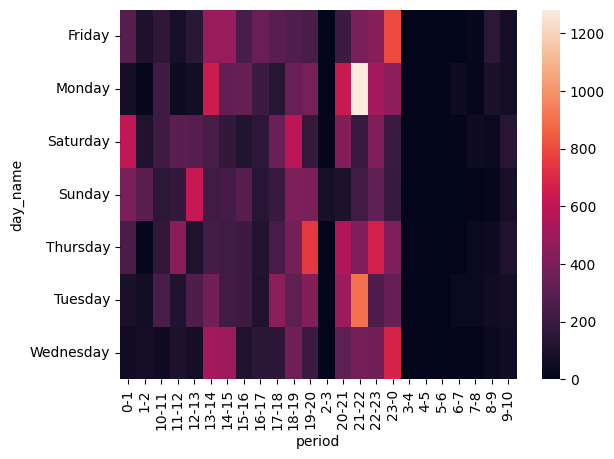

In [40]:
hours=[]
for i in df['hour']:
    if i==23:
        hours.append(str(i)+'-'+str('0'))
    elif i==0:
        hours.append(str('0')+'-'+str(i+1))
    else:
        hours.append(str(i)+'-'+str(i+1))
df['period']=hours
z=pd.pivot_table(index='day_name', columns='period',values='message',aggfunc='count',data=df).fillna(0)
plt.yticks(rotation=90)
sns.heatmap(z)


In [115]:
df

,date,user,message,year,month,day,hour,minute
1,2025-03-08 17:45:00,Naina Jain,‎Naina Jain created group “🎳 ”\n,2025,March,8,17,45
3,2025-03-08 17:46:00,Neel Lapsiwala,‎This message was deleted.\n‎,2025,March,8,17,46
4,2025-03-08 17:47:00,Neel Lapsiwala,‎video omitted\n‎,2025,March,8,17,47
5,2025-03-08 17:51:00,Neel Lapsiwala,‎video omitted\n,2025,March,8,17,51
6,2025-03-08 17:52:00,Ritweek,220 each\n‎,2025,March,8,17,52
...,...,...,...,...,...,...,...,...
35176,2026-01-01 00:30:00,Nishchay(ai),Nolan level shit banaya tha sab confuse😂😂\n‎,2026,January,1,0,30
35177,2026-01-01 00:30:00,Manav,‎sticker omitted\n,2026,January,1,0,30
35178,2026-01-01 09:05:00,Ritweek,Happy new year guys 🍷\n‎,2026,January,1,9,5
35179,2026-01-01 09:06:00,Neel Lapsiwala,‎GIF omitted\n‎,2026,January,1,9,6


In [116]:
h=df.groupby(['year','month'])['message'].count().reset_index()
g=(df.groupby(['year','month','user'])['message'].count()*100).reset_index()

ghost=g.merge(h,left_on=['year','month'],right_on=['year','month'])

ghost['percentage']=ghost['message_x']/ghost['message_y']
ghost[ghost['percentage']<2].groupby(['user'])['percentage'].count().reset_index()

,user,percentage
0,Samvanvitha(ai),10
1,‎You,4


In [137]:
l.str.cat(sep=" ")

AttributeError: 'list' object has no attribute 'str'